In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==============================
# 2. LOAD DATASET
# ==============================

file_path = "AB_NYC_2019.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
# ==============================
# 3. BASIC INFORMATION
# ==============================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical summary:")
display(df.describe(include="all").T)

Number of rows: 48895
Number of columns: 16

Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
d

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [4]:
# ==============================
# 4. MISSING VALUES
# ==============================

missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

print("Missing value summary:")
display(missing_table)

Missing value summary:


,Missing Values,Missing Percentage
reviews_per_month,10052,20.558339
last_review,10052,20.558339
host_name,21,0.042949
name,16,0.032723


In [5]:
# ==============================
# 5. DUPLICATE CHECK
# ==============================

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [6]:
# ==============================
# 7. CATEGORICAL DATA ANALYSIS
# ==============================

categorical_columns = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

for col in categorical_columns:
    print("\n==============================")
    print(col)
    print("==============================")
    print("Number of unique values:", df[col].nunique())
    print(df[col].value_counts().head(20))


neighbourhood_group
Number of unique values: 5
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

neighbourhood
Number of unique values: 221
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
East Harlem           1117
Greenpoint            1115
Chelsea               1113
Lower East Side        911
Astoria                900
Washington Heights     899
West Village           768
Financial District     744
Flatbush               621
Clinton Hill           572
Name: count, dtype: int64

room_type
Number of unique values: 3
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


In [7]:
# ==============================
# 8. NUMERICAL DATA ANALYSIS
# ==============================

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical columns:")
print(numerical_columns.tolist())

display(df[numerical_columns].describe().T)

Numerical columns:
['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [8]:
# ==============================
# 9. PRICE ANALYSIS
# ==============================

print("Price statistics:")
print(df["price"].describe())

print("\nNumber of zero-price listings:",
      (df["price"] == 0).sum())

print("\nNumber of listings above $500:",
      (df["price"] > 500).sum())

print("Number of listings above $1000:",
      (df["price"] > 1000).sum())

print("Number of listings above $2000:",
      (df["price"] > 2000).sum())

Price statistics:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Number of zero-price listings: 11

Number of listings above $500: 1044
Number of listings above $1000: 239
Number of listings above $2000: 86


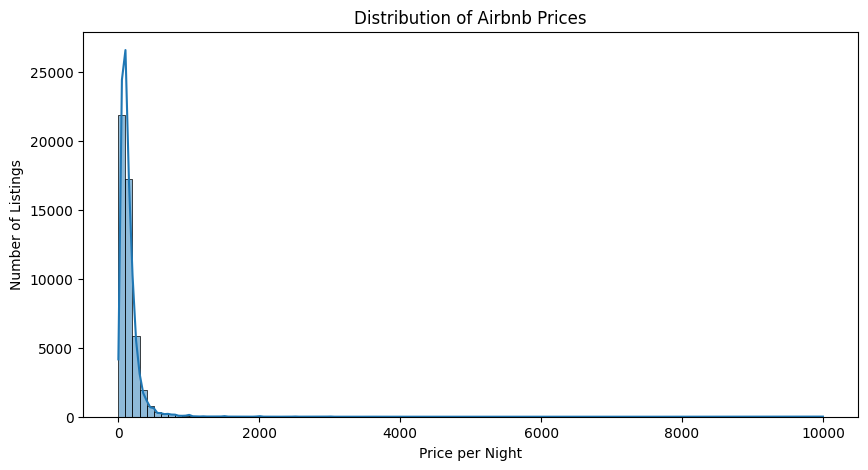

In [9]:
# ==============================
# 10. PRICE DISTRIBUTION
# ==============================

plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=100,
    kde=True
)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night")
plt.ylabel("Number of Listings")

plt.show()

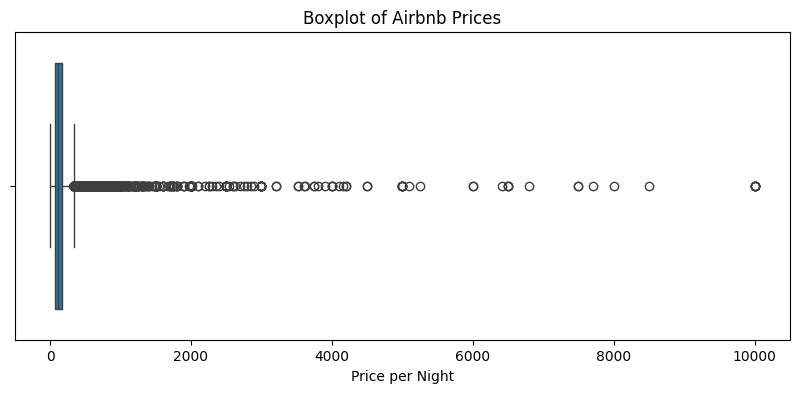

In [10]:
# ==============================
# 11. PRICE BOXPLOT
# ==============================

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price per Night")

plt.show()

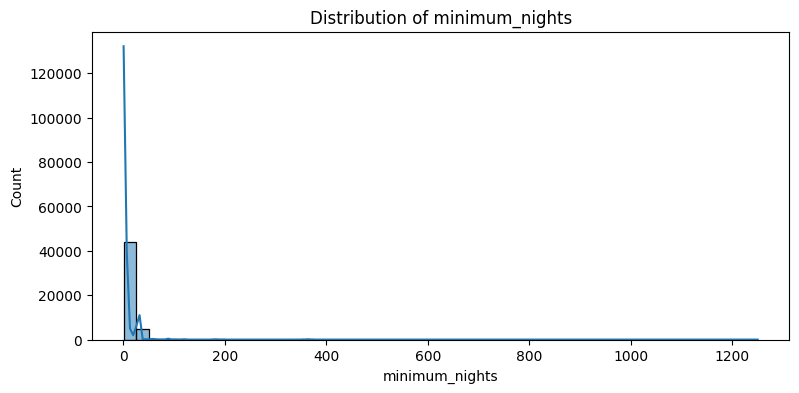

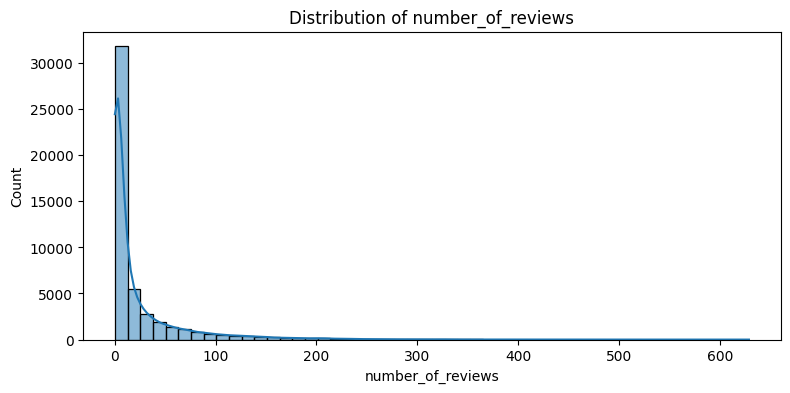

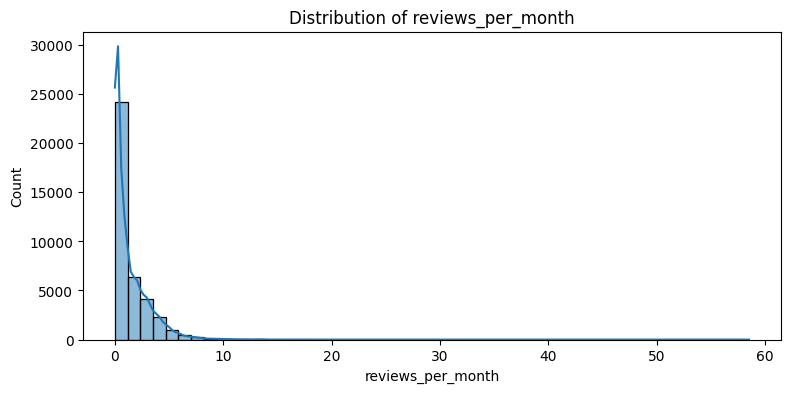

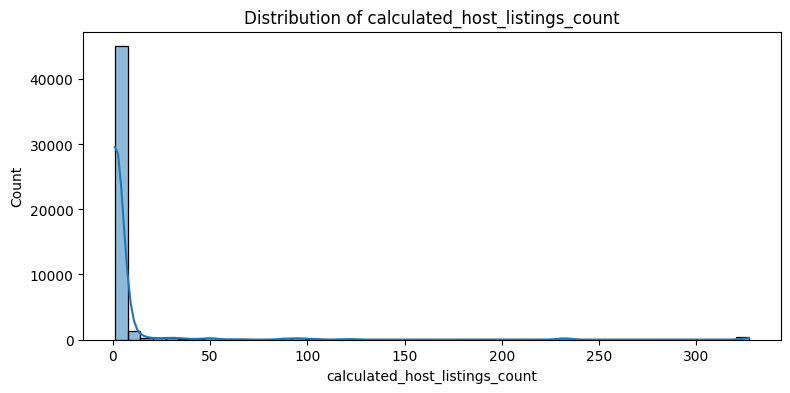

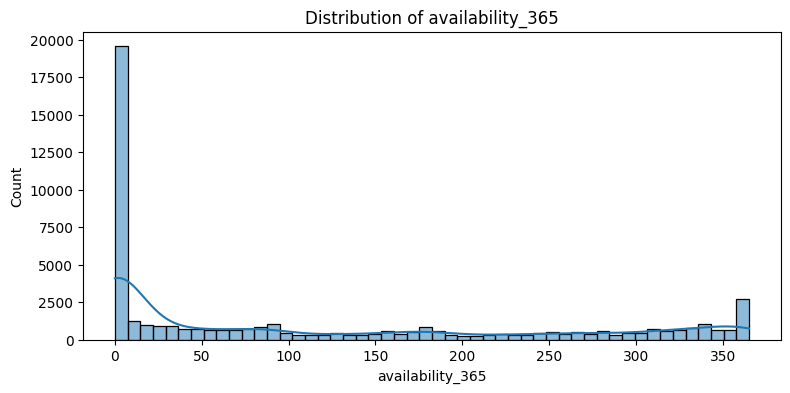

In [11]:
# ==============================
# 12. NUMERICAL DISTRIBUTIONS
# ==============================

important_numeric = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for col in important_numeric:

    plt.figure(figsize=(9, 4))

    sns.histplot(
        df[col].dropna(),
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

In [12]:
# ==============================
# 13. EXTREME VALUE CHECK
# ==============================

columns_to_check = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for col in columns_to_check:

    print("\n==============================")
    print(col)
    print("==============================")

    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Median:", df[col].median())
    print("Mean:", df[col].mean())

    print("99th percentile:",
          df[col].quantile(0.99))


price
Minimum: 0
Maximum: 10000
Median: 106.0
Mean: 152.7206871868289
99th percentile: 799.0

minimum_nights
Minimum: 1
Maximum: 1250
Median: 3.0
Mean: 7.029962163820431
99th percentile: 45.0

number_of_reviews
Minimum: 0
Maximum: 629
Median: 5.0
Mean: 23.274465691788528
99th percentile: 214.0

reviews_per_month
Minimum: 0.01
Maximum: 58.5
Median: 0.72
Mean: 1.3732214298586616
99th percentile: 7.195800000000018

calculated_host_listings_count
Minimum: 1
Maximum: 327
Median: 1.0
Mean: 7.143982002249719
99th percentile: 232.0

availability_365
Minimum: 0
Maximum: 365
Median: 45.0
Mean: 112.78132733408324
99th percentile: 365.0


In [13]:
# ==============================
# 14. REMOVE INVALID ZERO PRICES
# ==============================

before = len(df)

df = df[df["price"] > 0].copy()

after = len(df)

print("Rows before removing zero prices:", before)
print("Rows after removing zero prices:", after)
print("Rows removed:", before - after)

Rows before removing zero prices: 48895
Rows after removing zero prices: 48884
Rows removed: 11


In [14]:
# ==============================
# 15. HANDLE REVIEW INFORMATION
# ==============================

df["has_review"] = df["last_review"].notna().astype(int)

df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(df[
    ["number_of_reviews",
     "reviews_per_month",
     "has_review"]
].head(10))

   number_of_reviews  reviews_per_month  has_review
0                  9               0.21           1
1                 45               0.38           1
2                  0               0.00           0
3                270               4.64           1
4                  9               0.10           1
5                 74               0.59           1
6                 49               0.40           1
7                430               3.47           1
8                118               0.99           1
9                160               1.33           1


In [15]:
# ==============================
# 16. DATE FEATURE ENGINEERING
# ==============================

df["last_review"] = pd.to_datetime(
    df["last_review"],
    errors="coerce"
)

df["review_year"] = df["last_review"].dt.year

df["review_month"] = df["last_review"].dt.month

print(df[
    ["last_review",
     "review_year",
     "review_month",
     "has_review"]
].head(10))

  last_review  review_year  review_month  has_review
0  2018-10-19       2018.0          10.0           1
1  2019-05-21       2019.0           5.0           1
2         NaT          NaN           NaN           0
3  2019-07-05       2019.0           7.0           1
4  2018-11-19       2018.0          11.0           1
5  2019-06-22       2019.0           6.0           1
6  2017-10-05       2017.0          10.0           1
7  2019-06-24       2019.0           6.0           1
8  2017-07-21       2017.0           7.0           1
9  2019-06-09       2019.0           6.0           1


In [16]:
# ==============================
# 17. AVAILABILITY FEATURE
# ==============================

df["availability_ratio"] = (
    df["availability_365"] / 365
)

display(
    df[
        ["availability_365",
         "availability_ratio"]
    ].head()
)

,availability_365,availability_ratio
0,365,1.000000
1,355,0.972603
2,365,1.000000
3,194,0.531507
4,0,0.000000


In [17]:
# ==============================
# 18. LOG TRANSFORM FEATURES
# ==============================

skewed_features = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for col in skewed_features:

    new_col = "log_" + col

    df[new_col] = np.log1p(df[col])

display(
    df[
        skewed_features +
        ["log_" + col for col in skewed_features]
    ].head()
)

,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,log_minimum_nights,log_number_of_reviews,log_reviews_per_month,log_calculated_host_listings_count
0,1,9,0.21,6,0.693147,2.302585,0.190620,1.945910
1,1,45,0.38,2,0.693147,3.828641,0.322083,1.098612
2,3,0,0.00,1,1.386294,0.000000,0.000000,0.693147
3,1,270,4.64,1,0.693147,5.602119,1.729884,0.693147
4,10,9,0.10,1,2.397895,2.302585,0.095310,0.693147


In [18]:
# ==============================
# 19. SKEWNESS COMPARISON
# ==============================

for col in skewed_features:

    log_col = "log_" + col

    print(
        f"{col}: "
        f"{df[col].skew():.2f} "
        f"→ "
        f"{log_col}: "
        f"{df[log_col].skew():.2f}"
    )

minimum_nights: 21.83 → log_minimum_nights: 1.50
number_of_reviews: 3.69 → log_number_of_reviews: 0.36
reviews_per_month: 3.30 → log_reviews_per_month: 0.95
calculated_host_listings_count: 7.93 → log_calculated_host_listings_count: 3.28


In [19]:
# ==============================
# 20. PRICE BY ROOM TYPE
# ==============================

room_price = (
    df.groupby("room_type")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

display(room_price)

,count,mean,median
room_type,,,
Entire home/apt,25407,211.810918,160.0
Private room,22319,89.809131,70.0
Shared room,1158,70.248705,45.0


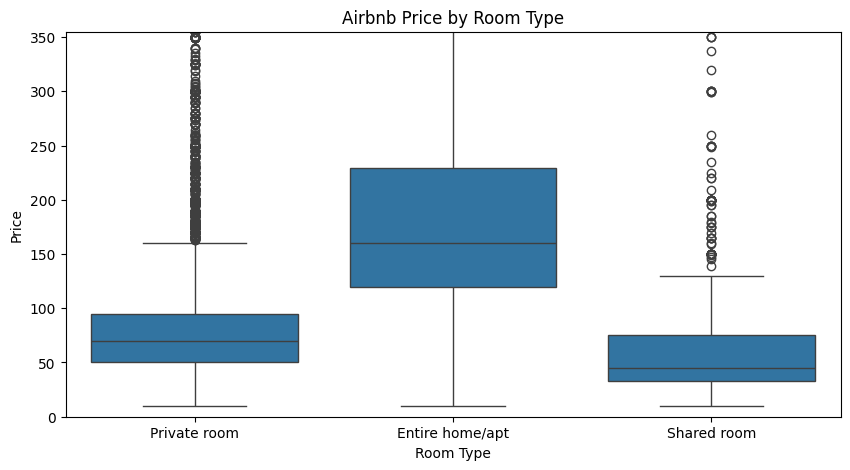

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.ylim(0, df["price"].quantile(0.95))

plt.title("Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")

plt.show()

In [21]:
# ==============================
# 21. PRICE BY NEIGHBOURHOOD GROUP
# ==============================

group_price = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

display(group_price)

,count,mean,median
neighbourhood_group,,,
Manhattan,21660,196.884903,150.0
Brooklyn,20095,124.438915,90.0
Queens,5666,99.517649,75.0
Staten Island,373,114.812332,75.0
Bronx,1090,87.577064,65.0


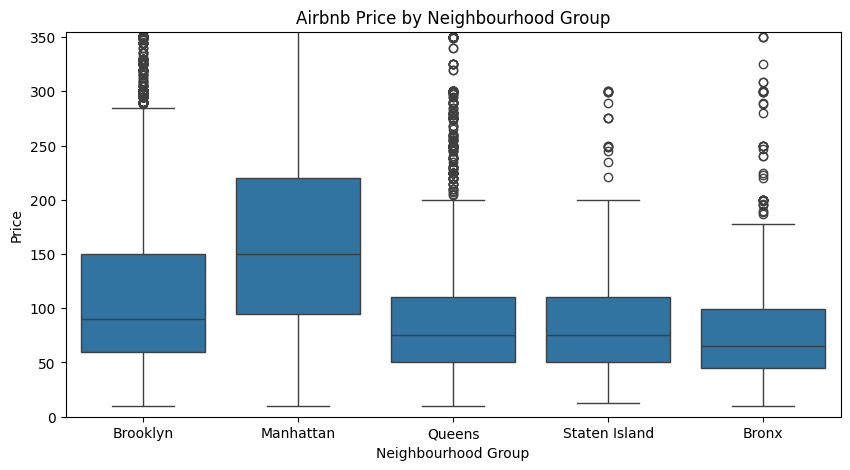

In [22]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.ylim(0, df["price"].quantile(0.95))

plt.title("Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")

plt.show()

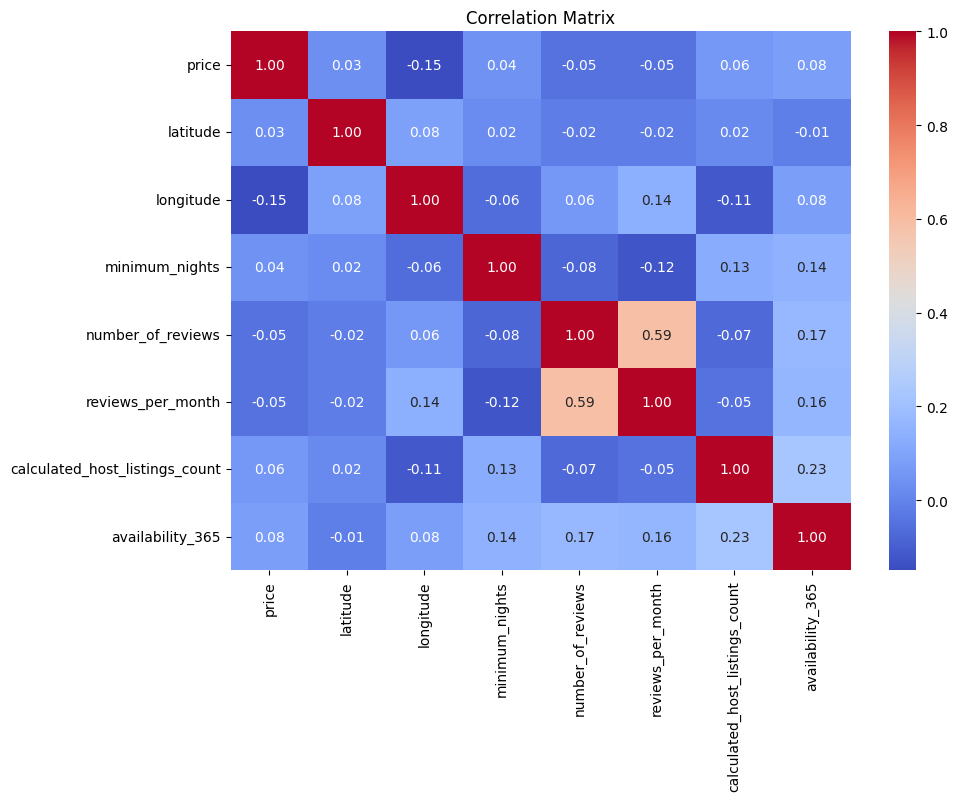

In [23]:
# ==============================
# 22. CORRELATION ANALYSIS
# ==============================

correlation_columns = [
    "price",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

correlation_matrix = df[
    correlation_columns
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [24]:
# ==============================
# 23. FEATURE SELECTION
# ==============================

features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "review_year",
    "review_month",
    "has_review",
    
    "log_calculated_host_listings_count",
    "availability_ratio"
]

target = "price"

X = df[features].copy()
y = df[target].copy()

print("Selected features:")
print(features)

print("\nNumber of selected features:", len(features))

print("\nTarget:")
print(target)

Selected features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'log_minimum_nights', 'log_number_of_reviews', 'log_reviews_per_month', 'review_year', 'review_month', 'has_review', 'log_calculated_host_listings_count', 'availability_ratio']

Number of selected features: 13

Target:
price


In [25]:
# ==============================
# 24. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 39107
Testing samples: 9777


In [26]:
# ==============================
# 25. DEFINE FEATURE TYPES
# ==============================

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "review_year",
    "review_month",
    "has_review",
    "log_calculated_host_listings_count",
    "availability_ratio"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Numerical features:
['latitude', 'longitude', 'log_minimum_nights', 'log_number_of_reviews', 'log_reviews_per_month', 'review_year', 'review_month', 'has_review', 'log_calculated_host_listings_count', 'availability_ratio']


In [27]:
# ==============================
# 26. PREPROCESSING PIPELINE
# ==============================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [28]:
# ==============================
# 27. DEFINE MODELS
# ==============================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Linear Regression
- Random Forest
- Extra Trees


In [29]:
# ==============================
# 28. CREATE MODEL PIPELINES
# ==============================

pipelines = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipelines[name] = pipeline

print("All pipelines created.")

All pipelines created.


In [30]:
# ==============================
# 29. TRAIN AND EVALUATE MODELS
# ==============================

results = []

for name, pipeline in pipelines.items():

    print("\nTraining:", name)

    pipeline.fit(X_train, y_train)

    # Training prediction
    train_predictions = pipeline.predict(X_train)

    # Testing prediction
    test_predictions = pipeline.predict(X_test)

    # Metrics
    train_mae = mean_absolute_error(
        y_train,
        train_predictions
    )

    test_mae = mean_absolute_error(
        y_test,
        test_predictions
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_predictions
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions
        )
    )

    train_r2 = r2_score(
        y_train,
        train_predictions
    )

    test_r2 = r2_score(
        y_test,
        test_predictions
    )

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

    print("Completed:", name)


Training: Linear Regression
Completed: Linear Regression

Training: Random Forest
Completed: Random Forest

Training: Extra Trees
Completed: Extra Trees


In [31]:
# ==============================
# 30. MODEL COMPARISON
# ==============================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test RMSE"
)

display(results_df)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,72.079384,71.299670,233.715709,184.924116,0.120274,0.145844
1,Random Forest,24.563057,66.493587,86.400044,196.460639,0.879774,0.035947
2,Extra Trees,0.002302,69.189093,0.195698,214.621618,0.999999,-0.150527


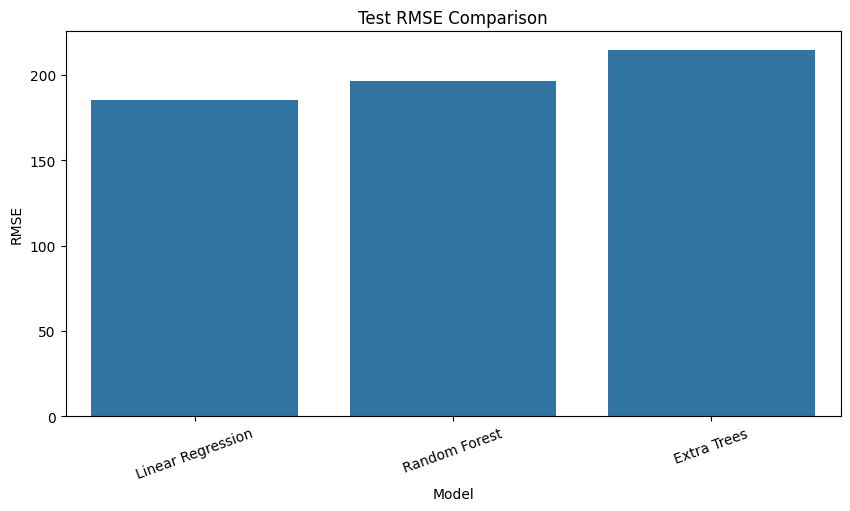

In [32]:
# ==============================
# 31. RMSE COMPARISON
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test RMSE"
)

plt.title("Test RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

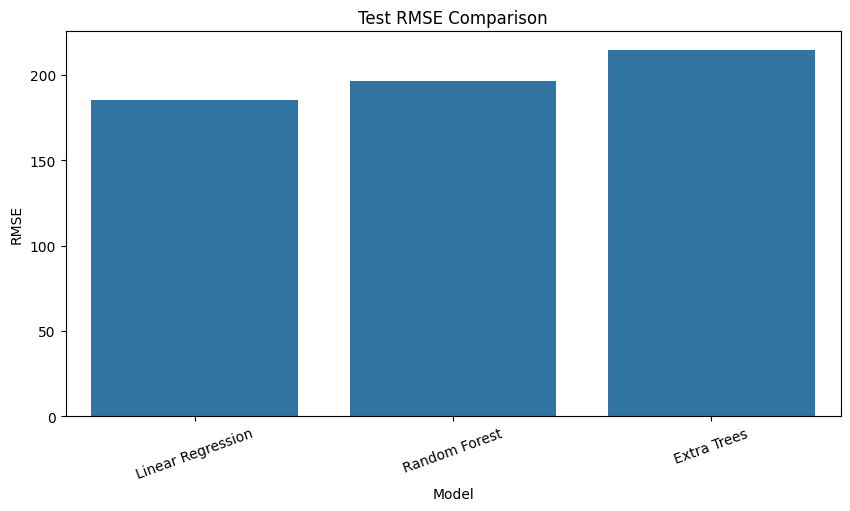

In [33]:
# ==============================
# 31. RMSE COMPARISON
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test RMSE"
)

plt.title("Test RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

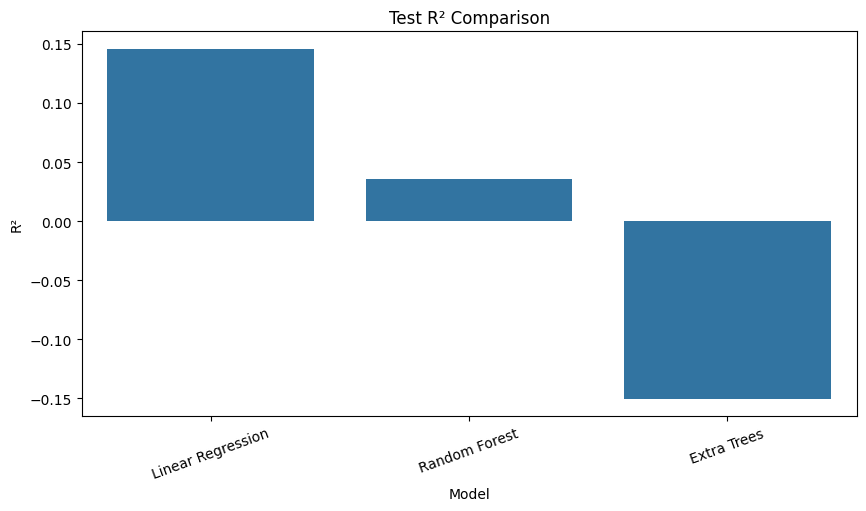

In [34]:
# ==============================
# 33. R2 COMPARISON
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test R2"
)

plt.title("Test R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=20)

plt.show()

In [35]:
# ==============================
# 34. SELECT BEST MODEL
# ==============================

best_model_name = results_df.iloc[0]["Model"]

print("Best baseline model:", best_model_name)

Best baseline model: Linear Regression


In [37]:
# ==============================
# 35. RANDOM FOREST TUNING
# ==============================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [38]:
rf_param_grid = {

    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        None,
        10,
        20,
        30,
        40
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.5
    ]
}

In [39]:
# ==============================
# 36. RANDOMIZED SEARCH
# ==============================

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,

    param_distributions=rf_param_grid,

    n_iter=20,

    scoring="neg_root_mean_squared_error",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

print("Starting hyperparameter tuning...")

rf_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Hyperparameter tuning completed.


In [40]:
# ==============================
# 37. BEST PARAMETERS
# ==============================

print("Best parameters:")

for parameter, value in rf_search.best_params_.items():
    print(parameter, "=", value)

print("\nBest CV RMSE:",
      -rf_search.best_score_)

Best parameters:
model__n_estimators = 200
model__min_samples_split = 5
model__min_samples_leaf = 4
model__max_features = 0.5
model__max_depth = None

Best CV RMSE: 227.19431069896692


In [41]:
# ==============================
# 38. EVALUATE TUNED MODEL
# ==============================

best_rf = rf_search.best_estimator_

train_pred = best_rf.predict(X_train)

test_pred = best_rf.predict(X_test)

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("========== TUNED RANDOM FOREST ==========")

print("Train MAE :", train_mae)
print("Test MAE  :", test_mae)

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

print("Train R²  :", train_r2)
print("Test R²   :", test_r2)

========== TUNED RANDOM FOREST ==========
Train MAE : 46.59738754167924
Test MAE  : 62.94268753404362
Train RMSE: 184.6321577276407
Test RMSE : 176.72940834509637
Train R²  : 0.450982195985143
Test R²   : 0.21986903199532315


In [42]:
# ==============================
# 39. OVERFITTING CHECK
# ==============================

print("========== OVERFITTING CHECK ==========")

print(
    f"Train R²: {train_r2:.4f}"
)

print(
    f"Test R² : {test_r2:.4f}"
)

r2_gap = train_r2 - test_r2

print(
    f"R² difference: {r2_gap:.4f}"
)

if r2_gap > 0.15:

    print(
        "Warning: The model may be overfitting."
    )

elif r2_gap > 0.08:

    print(
        "Moderate train-test gap detected."
    )

else:

    print(
        "Train-test performance is reasonably close."
    )

========== OVERFITTING CHECK ==========
Train R²: 0.4510
Test R² : 0.2199
R² difference: 0.2311
